### visualize the specific lakes via remote sensing image

In [ ]:
import rasterio as rio 
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt  
from matplotlib.colors import LinearSegmentedColormap   
from pyrsimg import add_scale_bar, add_north_arrow, imgShow 


In [2]:
colors_dem = [(128/255, 205/255, 193/255), (245/255, 245/255, 245/255), \
          (223/255, 194/255, 125/255), (166/255, 97/255, 26/255)]
cmap_dem = LinearSegmentedColormap.from_list('linear color', colors_dem)


In [5]:
## region of yunnan
path_vec_ygp = 'data/boundary/ygp_region.gpkg'
path_srtm_down = 'data/dem/SRTMGL3_005deg.tif' 
## boundaries of nine lakes
dir_img_lakes = 'data/lakes-specific/rsimg/'
dir_vec_lakes = 'data/lakes-specific/vector-by-rsimg/'
path_chenghai_vec = dir_vec_lakes + 'chenghai_s2_20240418.gpkg'
path_dianchi_vec = dir_vec_lakes + 'dianchi_s2_20240415.gpkg'
path_erhai_vec = dir_vec_lakes + 'erhai_s2_20240801.gpkg'
path_fuxian_vec = dir_vec_lakes + 'fuxian_s2_20240415.gpkg'
path_lugu_vec = dir_vec_lakes + 'lugu_s2_20240523.gpkg'
path_qilu_vec = dir_vec_lakes + 'qilu_s2_20240415.gpkg'
path_xingyun_vec = dir_vec_lakes + 'xingyun_s2_20240415.gpkg'
path_yangzonghai_vec = dir_vec_lakes + 'yangzonghai_s2_20240415.gpkg'
path_yilong_vec = dir_vec_lakes + 'yilong_s2_20240415.gpkg'
## remote sensing image of nine lakes
path_chenghai_img = dir_img_lakes + 'chenghai_s2_20240418.tif'
path_lugu_img = dir_img_lakes + 'lugu_s2_20240523.tif'
path_erhai_img = dir_img_lakes + 'erhai_s2_20240801.tif'
path_2lakes_img = dir_img_lakes + 'qilu_yilong_s2_20240415.tif'
path_4lakes_img = dir_img_lakes + 'dianchi_fuxian_yangzonghai_xingyun_s2_20210317.tif'


In [6]:
## read yunnan vector
yunnan_vec_gpd = gpd.read_file(path_vec_ygp)
## read lake vector
chenghai_vec_gpd = gpd.read_file(path_chenghai_vec)
dianchi_vec_gpd = gpd.read_file(path_dianchi_vec)
erhai_vec_gpd = gpd.read_file(path_erhai_vec)
fuxian_vec_gpd = gpd.read_file(path_fuxian_vec)
lugu_vec_gpd = gpd.read_file(path_lugu_vec)
qilu_vec_gpd = gpd.read_file(path_qilu_vec)
xingyun_vec_gpd = gpd.read_file(path_xingyun_vec)
yilong_vec_gpd = gpd.read_file(path_yilong_vec)
yangzonghai_vec_gpd = gpd.read_file(path_yangzonghai_vec)
## read image
src_chenghai_img = rio.open(path_chenghai_img)
src_erhai_img = rio.open(path_erhai_img)
src_lugu_img = rio.open(path_lugu_img)
src_2lakes_img = rio.open(path_2lakes_img)
src_4lakes_img = rio.open(path_4lakes_img)


In [7]:
points_dict = {}
points_name = ['chenghai', 'dianchi', 'erhai', 'fuxian', 'lugu', 'qilu', 'xingyun', 'yangzonghai', 'yilong']
points_gpd = [chenghai_vec_gpd, dianchi_vec_gpd, erhai_vec_gpd, 
              fuxian_vec_gpd, lugu_vec_gpd, qilu_vec_gpd, xingyun_vec_gpd, 
              yangzonghai_vec_gpd, yilong_vec_gpd]
for i, name in enumerate(points_name):
    points_dict[name] = points_gpd[i].to_crs(epsg=3857).centroid.to_crs(epsg=4326)
points_dict


{'chenghai': 0    POINT (100.66397 26.55042)
 dtype: geometry,
 'dianchi': 0    POINT (102.68837 24.81727)
 dtype: geometry,
 'erhai': 0    POINT (100.19521 25.78852)
 dtype: geometry,
 'fuxian': 0    POINT (102.88641 24.51948)
 dtype: geometry,
 'lugu': 0    POINT (100.78858 27.70741)
 dtype: geometry,
 'qilu': 0    POINT (102.7726 24.16613)
 dtype: geometry,
 'xingyun': 0    POINT (102.78426 24.33719)
 dtype: geometry,
 'yangzonghai': 0    POINT (103.00236 24.9119)
 dtype: geometry,
 'yilong': 0    POINT (102.56719 23.67282)
 dtype: geometry}

In [ ]:
# region = [96, 107.5, 20.5, 30]
# region_x = [region[0], region[1], region[1], region[0], region[0]]
# region_y = [region[2], region[2], region[3], region[3], region[2]]
# fig = plt.figure(figsize=(3, 3))
# plt.rcParams.update({'font.size':12})
# ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
# ax.set_extent([70, 130, 0, 45.0])
# ### plot hma boundary
# gridl = ax.gridlines(draw_labels=False, linewidth=0.)
# yunnan_vec_gpd.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1)
# ### plot rectangle
# # plt.plot(region_x, region_y, transform=ccrs.PlateCarree(), linewidth=2, color='blue')
# ax.tick_params(labelbottom=True,  labeltop=True, labelleft=True, labelright=True,
#                      bottom=True, top=True,      left=True, right=True, direction="in")                     
# ### plot auxlliary data
# ax.add_feature(cfeature.LAND, facecolor='WhiteSmoke')
# ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)
# ax.add_feature(cfeature.OCEAN)

# ### Set figure
# ax.set_xticks([75,  90, 105, 120])
# ax.set_yticks([0, 15, 30, 45])
# gridl.xlabel_style = {'size': 10}
# gridl.ylabel_style = {'size': 10}


In [8]:
src_srtm_down = rio.open(path_srtm_down)
src_srtm_down.read()
src_srtm_down.bounds
src_srtm_down_extent = [
    src_srtm_down.bounds.left, src_srtm_down.bounds.right,
    src_srtm_down.bounds.bottom, src_srtm_down.bounds.top]
src_srtm_down_extent


[94.8995833332709, 115.0995833332709, 17.900416666672324, 35.100416666672324]

/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


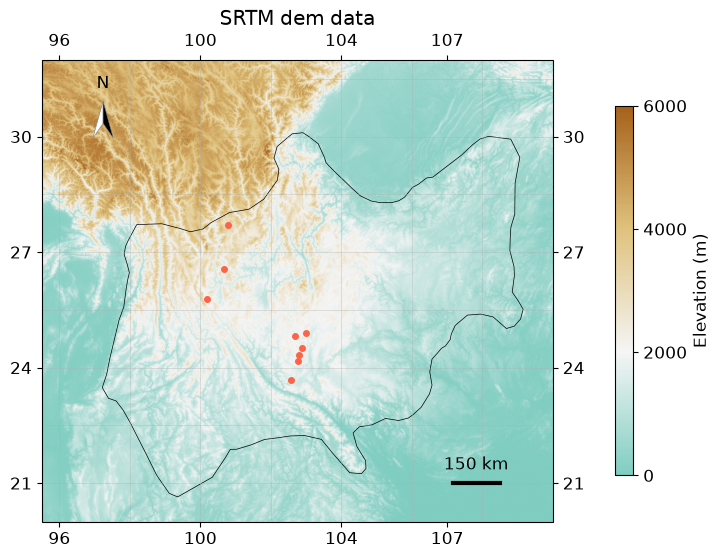

In [9]:
src_srtm_down = rio.open(path_srtm_down)
src_srtm_down_extent = [
    src_srtm_down.bounds.left, src_srtm_down.bounds.right, 
    src_srtm_down.bounds.bottom, src_srtm_down.bounds.top]

### visualize dem 
fig = plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size':12})
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([95.5, 110, 20, 32])
ax_img = ax.imshow(src_srtm_down.read()[0], cmap=cmap_dem, clim=[0, 6000], alpha=1, extent=src_srtm_down_extent)
ax.set_title('SRTM dem data')
cbar = fig.colorbar(ax_img, ax=ax, fraction=0.03, pad=0.1, label='Elevation (m)', shrink=0.8, ticks=[0, 2000, 4000, 6000])
cbar.ax.tick_params(labelsize=12)
### Visualize vector
yunnan_vec_gpd.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.5)
gridl = ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5, zorder=1)
ax.set_xticks([96, 100, 104, 107])
ax.set_yticks([21, 24, 27, 30])
ax.tick_params(labelbottom=True,  labeltop=True, labelleft=True, labelright=True,
                     bottom=True, top=True, left=True, right=True)                     
gridl.xlabel_style = {'size': 10}
gridl.ylabel_style = {'size': 10}
add_scale_bar(ax, length=150, loc=(0.85, 0.08), linewidth=3)
add_north_arrow(ax=ax, loc=(0.12, 0.87), size = (0.04, 0.04), font_N=12, edge_color_narrow='gray', edge_width_narrow=0.4)

### add locations of lakes
points_name = list(points_dict.keys())
for i, point_gpd in enumerate(points_dict.values()):
    point_gpd.plot(ax=ax, color='Tomato', markersize=16, marker='o')
    # ax.text(point_gpd[0].x, point_gpd[0].y, points_name[i])
# plt.savefig('figures/lakes_yunnan.png', bbox_inches='tight', dpi=100)


#### show remote sensing image

In [10]:
## get extent and crs of lakes
extent_chenghai = [src_chenghai_img.bounds.left, src_chenghai_img.bounds.right, src_chenghai_img.bounds.bottom, src_chenghai_img.bounds.top]
extent_erhai = [src_erhai_img.bounds.left, src_erhai_img.bounds.right, src_erhai_img.bounds.bottom, src_erhai_img.bounds.top]
extent_lugu = [src_lugu_img.bounds.left, src_lugu_img.bounds.right, src_lugu_img.bounds.bottom, src_lugu_img.bounds.top]
crs_chenghai = ccrs.epsg(src_chenghai_img.crs.to_epsg())
crs_erhai = ccrs.epsg(src_erhai_img.crs.to_epsg())
crs_lugu = ccrs.epsg(src_lugu_img.crs.to_epsg())   


In [11]:
## print the wgs84 extent of lakes
print('chenghai:', chenghai_vec_gpd.total_bounds)
print('erhai:', erhai_vec_gpd.total_bounds)
print('lugu:', lugu_vec_gpd.total_bounds)


chenghai: [100.63776935  26.46270667 100.69175564  26.6303591 ]
erhai: [100.09632177  25.60251631 100.28881855  25.96415456]
lugu: [100.7443843   27.66375274 100.83568452  27.74883192]


/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


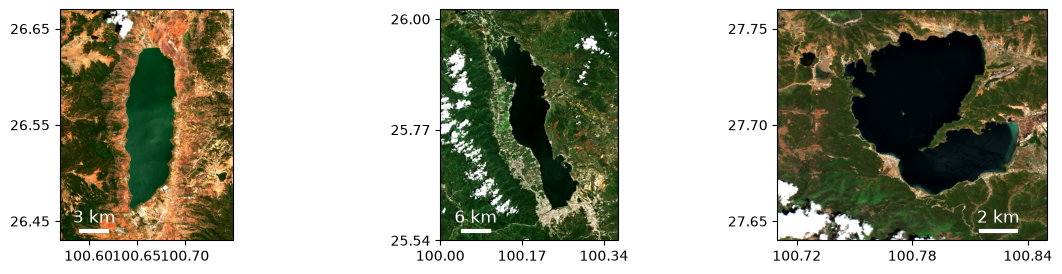

In [ ]:
## !!! avoid to use GeoAxes.gridlines, which will cause some problems.
plt.rcParams.update({'font.size':10})
fig, ax = plt.subplots(1, 3, figsize=(14, 3), subplot_kw={'projection': ccrs.PlateCarree()})    
### chenghai
ax[0].set_extent([100.57, 100.75, 26.43, 26.67])
imgShow(src_chenghai_img.read().transpose(1,2,0), color_bands = (2,1,0), 
              clip_percent=[5,95], ax=ax[0], extent=extent_chenghai, transform=crs_chenghai)
add_scale_bar(ax=ax[0], length=3, loc=(0.2, 0.04), linewidth=3, color_bar='white', color_text='white')
ax[0].set_xticks([100.60, 100.65, 100.70]); ax[0].set_yticks([26.45, 26.55, 26.65]);


# ## erhai
ax[1].set_extent([100, 100.37, 25.54, 26.02])
imgShow(src_erhai_img.read().transpose(1,2,0), color_bands = (2,1,0), 
              clip_percent=[5,95], ax=ax[1], extent=extent_erhai, transform=crs_erhai)
add_scale_bar(ax=ax[1], length=6, loc=(0.2, 0.04), linewidth=3, color_bar='white', color_text='white')
ax[1].set_xticks([100, 100.17, 100.34]); ax[1].set_yticks([25.54, 25.77, 26]);

# ## lugu
ax[2].set_extent([100.71, 100.85, 27.64, 27.76])
imgShow(src_lugu_img.read().transpose(1,2,0), color_bands = (2,1,0), 
              clip_percent=[5,95], ax=ax[2], extent=extent_lugu, transform=crs_lugu)
add_scale_bar(ax=ax[2], length=2, loc=(0.82, 0.04), linewidth=3, color_bar='white', color_text='white')
ax[2].set_xticks([100.72, 100.78, 100.84]); ax[2].set_yticks([27.65, 27.70, 27.75]); 


In [32]:
## get extent and crs of lakes
extent_qilu_yilong = [src_2lakes_img.bounds.left, src_2lakes_img.bounds.right, src_2lakes_img.bounds.bottom, src_2lakes_img.bounds.top]
crs_qilu_yilong = ccrs.epsg(src_2lakes_img.crs.to_epsg())


In [33]:
print('qilu:', qilu_vec_gpd.total_bounds)
print('yilong:', yilong_vec_gpd.total_bounds)


qilu: [102.71828647  24.13751316 102.81529464  24.20404323]
yilong: [102.50086225  23.64804577 102.62839214  23.70079086]


/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


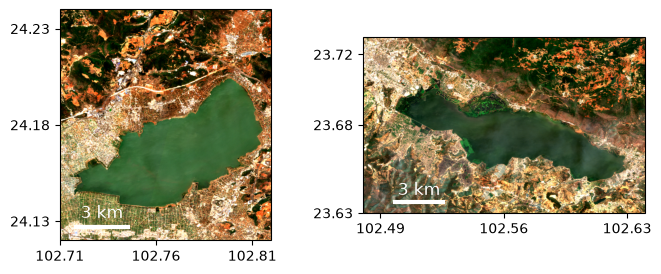

In [34]:
fig, ax = plt.subplots(1,2, figsize=(8, 3), subplot_kw={'projection': ccrs.PlateCarree()})
plt.rcParams.update({'font.size':10})
## qilu
ax[0].set_extent([102.71, 102.82, 24.12, 24.24])
imgShow(src_2lakes_img.read().transpose(1,2,0), color_bands = (2,1,0),
              clip_percent=[5,95], ax=ax[0], extent=extent_qilu_yilong, transform=crs_qilu_yilong)
add_scale_bar(ax=ax[0], length=3, loc=(0.2, 0.06), linewidth=3, color_bar='white', color_text='white')
ax[0].set_xticks([102.71, 102.76, 102.81]); ax[0].set_yticks([24.13, 24.18, 24.23]);

## yilong
ax[1].set_extent([102.48, 102.64, 23.63, 23.73])
imgShow(src_2lakes_img.read().transpose(1,2,0), color_bands = (2,1,0),
              clip_percent=[5,95], ax=ax[1], extent=extent_qilu_yilong, transform=crs_qilu_yilong)
add_scale_bar(ax=ax[1], length=3, loc=(0.2, 0.06), linewidth=3, color_bar='white', color_text='white')
ax[1].set_xticks([102.49, 102.56, 102.63]); ax[1].set_yticks([23.63, 23.68, 23.72]);


In [35]:
## get extent and crs of lakes
extent_dianchi_fuxian_xingyun_yangzonghai = [src_4lakes_img.bounds.left, src_4lakes_img.bounds.right, src_4lakes_img.bounds.bottom, src_4lakes_img.bounds.top]
crs_dianchi_fuxian_xingyun_yangzonghai = ccrs.epsg(src_4lakes_img.crs.to_epsg())


In [36]:
print('dianchi:', dianchi_vec_gpd.total_bounds)
print('fuxian:', fuxian_vec_gpd.total_bounds)
print('xingyun:', xingyun_vec_gpd.total_bounds)
print('yangzonghai:', yangzonghai_vec_gpd.total_bounds)


dianchi: [102.59653028  24.66901512 102.78559272  24.96313528]
fuxian: [102.82089107  24.35515808 102.95765363  24.63299861]
xingyun: [102.75347764  24.2895903  102.80828019  24.38509493]
yangzonghai: [102.98016708  24.85775338 103.02704546  24.96634837]


/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/luo/miniconda3/envs/ygp_water/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


[Text(102.97, 0, '102.97'),
 Text(103.0, 0, '103.00'),
 Text(103.03, 0, '103.03')]

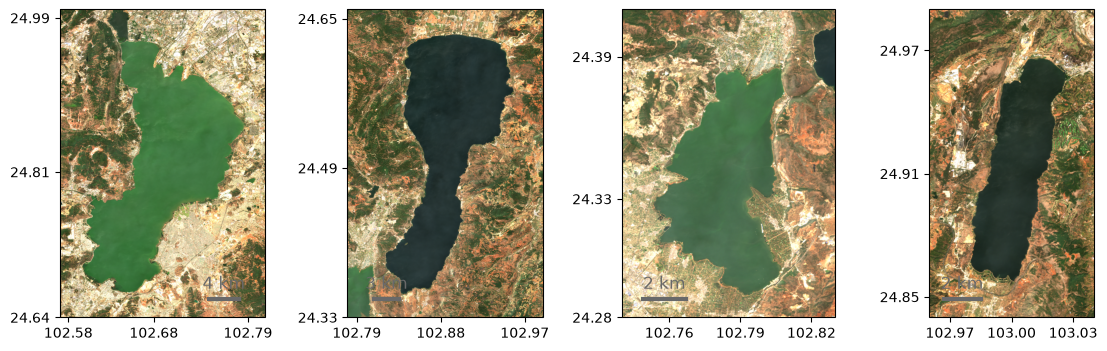

In [37]:
fig, ax = plt.subplots(1,4, figsize=(14, 4), subplot_kw={'projection': ccrs.PlateCarree()})
plt.rcParams.update({'font.size':10})
## dianchi
ax[0].set_extent([102.57, 102.81, 24.64, 25])
imgShow(src_4lakes_img.read().transpose(1,2,0), color_bands = (2,1,0),
              clip_percent=[5,95], ax=ax[0], extent=extent_dianchi_fuxian_xingyun_yangzonghai, transform=crs_dianchi_fuxian_xingyun_yangzonghai)
add_scale_bar(ax=ax[0], length=4, loc=(0.8, 0.06), linewidth=3, color_bar='DimGrey', color_text='DimGrey')
ax[0].set_xticks([102.58, 102.68, 102.79]); ax[0].set_yticks([24.64, 24.81, 24.99]);

## fuxian
ax[1].set_extent([102.78, 102.99, 24.33, 24.66])
imgShow(src_4lakes_img.read().transpose(1,2,0), color_bands = (2,1,0),
              clip_percent=[5,95], ax=ax[1], extent=extent_dianchi_fuxian_xingyun_yangzonghai, transform=crs_dianchi_fuxian_xingyun_yangzonghai)
add_scale_bar(ax=ax[1], length=3, loc=(0.2, 0.06), linewidth=3, color_bar='DimGrey', color_text='DimGrey')
ax[1].set_xticks([102.79, 102.88, 102.97]); ax[1].set_yticks([24.33, 24.49, 24.65]);

## xingyun 
ax[2].set_extent([102.74, 102.83, 24.28, 24.41])
imgShow(src_4lakes_img.read().transpose(1,2,0), color_bands = (2,1,0),
              clip_percent=[5,95], ax=ax[2], extent=extent_dianchi_fuxian_xingyun_yangzonghai, transform=crs_dianchi_fuxian_xingyun_yangzonghai)
add_scale_bar(ax=ax[2], length=2, loc=(0.2, 0.06), linewidth=3, color_bar='DimGrey', color_text='DimGrey')
ax[2].set_xticks([102.76, 102.79, 102.82]); ax[2].set_yticks([24.28, 24.33, 24.39]);

## yangzonghai
ax[3].set_extent([102.96, 103.04, 24.84, 24.99])
imgShow(src_4lakes_img.read().transpose(1,2,0), color_bands = (2,1,0),
              clip_percent=[5,95], ax=ax[3], extent=extent_dianchi_fuxian_xingyun_yangzonghai, transform=crs_dianchi_fuxian_xingyun_yangzonghai)
add_scale_bar(ax=ax[3], length=2, loc=(0.2, 0.06), linewidth=3, color_bar='DimGrey', color_text='DimGrey')
ax[3].set_xticks([102.97, 103, 103.03]); ax[3].set_yticks([24.85, 24.91, 24.97]); 
ax[3].set_xticklabels(['102.97', '103.00', '103.03'])
